In [1]:
from src.utils.file_utils import unzip_with_progress

2026-06-08 15:58:45.438 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /home/gaurav/Documents/burnout_classifier


In [2]:
data_path = "/home/gaurav/Documents/burnout_classifier/data/raw/zipped/archive.zip"
save_path = "/home/gaurav/Documents/burnout_classifier/data/raw/unzipped/"

In [3]:
unzip_with_progress(zip_file_path=data_path, extract_to=save_path)

Output()

PosixPath('/home/gaurav/Documents/burnout_classifier/data/raw/unzipped')

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv(
    "/home/gaurav/Documents/burnout_classifier/data/raw/unzipped/raw_data.csv"
)

In [9]:
import matplotlib.pyplot as plt

In [10]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [12]:
df["Burnout_Risk_Level"].value_counts() / df.shape[0]

Burnout_Risk_Level
Medium    0.42288
Low       0.32738
High      0.24974
Name: count, dtype: float64

In [16]:
high_burnout = df[df["Burnout_Risk_Level"] == "High"]
low_burnout = df[df["Burnout_Risk_Level"] == "Low"]
medium_burnout = df[df["Burnout_Risk_Level"] == "Medium"]

In [34]:
df["GenAI_Hour_Bins"] = pd.qcut(df["Weekly_GenAI_Hours"], q=5)

In [36]:
fig_dir = "/home/gaurav/Documents/burnout_classifier/reports/figures"

<Axes: xlabel='GenAI_Hour_Bins'>

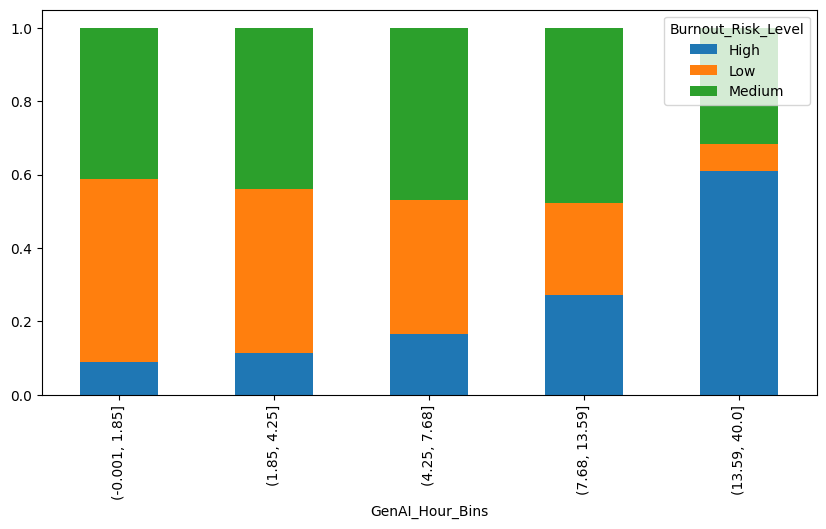

In [35]:
table = pd.crosstab(df["GenAI_Hour_Bins"], df["Burnout_Risk_Level"], normalize="index")

table.plot(kind="bar", stacked=True, figsize=(10, 5))

### EDA

In [38]:
# Pre vs Post GPA Trend

In [43]:
df["Gpa_Change"] = df["Post_Semester_GPA"] - df["Pre_Semester_GPA"]

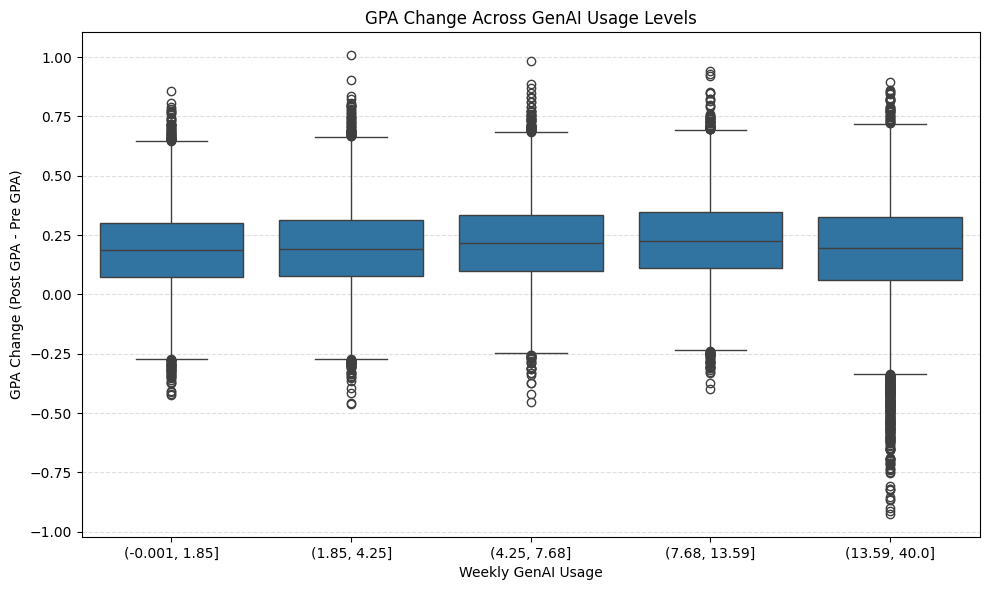

In [91]:
import seaborn as sns
from pathlib import Path

plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="GenAI_Hour_Bins", y="Gpa_Change")

plt.title("GPA Change Across GenAI Usage Levels")
plt.xlabel("Weekly GenAI Usage")
plt.ylabel("GPA Change (Post GPA - Pre GPA)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(Path(fig_dir) / "figure_1.png")
plt.show()

In [60]:
high_geni_usage = df[
    (df["Weekly_GenAI_Hours"] >= 13.59) & (df["Weekly_GenAI_Hours"] <= 40.0)
]

In [71]:
decline_gpa = high_geni_usage[high_geni_usage["Gpa_Change"] < 0]
improved_gpa = high_geni_usage[high_geni_usage["Gpa_Change"] > 0]
no_change_gpa = high_geni_usage[high_geni_usage["Gpa_Change"] == 0]

In [72]:
no_change_gpa

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GenAI_Hour_Bins,Gpa_Change
1856,101857,Arts,Freshman,3.392,15.78,Debugging/Troubleshooting,Beginner,2,False,5.42,3,Allowed_With_Citation,6,3.392,79.94,High,"(13.59, 40.0]",0.0
3717,103718,STEM,Freshman,3.807,15.73,Summarizing_Reading,Advanced,3,True,7.67,4,Actively_Encouraged,2,3.807,100.00,Low,"(13.59, 40.0]",0.0
17914,117915,STEM,Senior,2.513,40.00,Summarizing_Reading,Intermediate,3,False,3.43,7,Actively_Encouraged,10,2.513,78.05,High,"(13.59, 40.0]",0.0
19737,119738,Business,Sophomore,2.398,20.23,Ideation,Intermediate,2,False,9.96,3,Allowed_With_Citation,6,2.398,76.86,Medium,"(13.59, 40.0]",0.0
26920,126921,Arts,Freshman,3.739,15.14,Copywriting/Drafting,Advanced,3,False,3.67,3,Allowed_With_Citation,6,3.739,97.99,Medium,"(13.59, 40.0]",0.0
27143,127144,Humanities,Freshman,3.649,34.00,Debugging/Troubleshooting,Intermediate,4,False,10.20,6,Strict_Ban,9,3.649,68.84,High,"(13.59, 40.0]",0.0
31685,131686,Humanities,Graduate,3.296,20.16,Direct_Answer_Generation,Intermediate,5,True,11.19,4,Actively_Encouraged,3,3.296,70.42,Medium,"(13.59, 40.0]",0.0
32830,132831,Business,Junior,3.287,29.95,Ideation,Intermediate,3,False,6.40,7,Actively_Encouraged,8,3.287,71.79,High,"(13.59, 40.0]",0.0
38548,138549,Medical,Freshman,3.741,21.31,Summarizing_Reading,Beginner,3,True,13.90,6,Strict_Ban,8,3.741,79.24,Medium,"(13.59, 40.0]",0.0
46468,146469,Business,Senior,3.536,34.08,Ideation,Intermediate,2,True,6.16,7,Actively_Encouraged,7,3.536,62.51,High,"(13.59, 40.0]",0.0


In [75]:
from rich import print

In [76]:
print(
    f"Out of {high_geni_usage.shape[0]} Total Students with High Gen Ai Usage.\n{decline_gpa.shape[0]} Students GPA Declined.\n{improved_gpa.shape[0]} Students GPA Improved.\n{no_change_gpa.shape[0]} Students Had No Change."
)

Out of 10004 Total Students with High Gen Ai Usage.
1708 Students GPA Declined.
8285 Students GPA Improved.
11 Students Had No Change.

In [94]:
import numpy as np

outcome_df = df.copy()

outcome_df["Outcome"] = np.where(
    outcome_df["Gpa_Change"] >= outcome_df["Gpa_Change"].median(),
    "Improved",
    "Declined",
)

table = pd.crosstab(
    outcome_df["Prompt_Engineering_Skill"], outcome_df["Outcome"], normalize="index"
).mul(100)

<Figure size 1000x600 with 0 Axes>

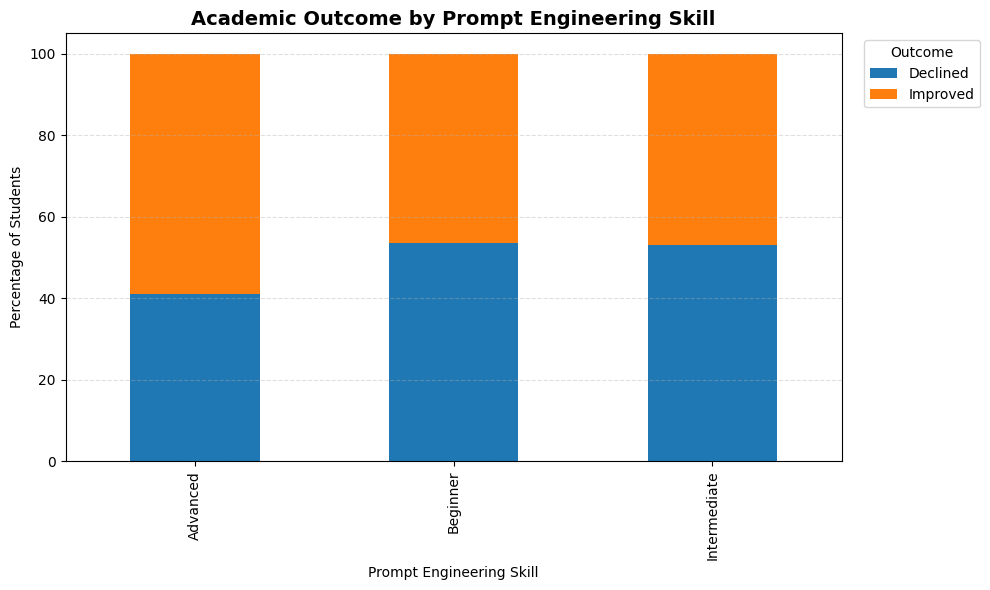

In [96]:
plt.figure(figsize=(10, 6))

table.plot(kind="bar", stacked=True, figsize=(10, 6))

plt.title(
    "Academic Outcome by Prompt Engineering Skill", fontsize=14, fontweight="bold"
)

plt.xlabel("Prompt Engineering Skill")
plt.ylabel("Percentage of Students")

plt.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(Path(fig_dir) / "fig_2.png")
plt.show()

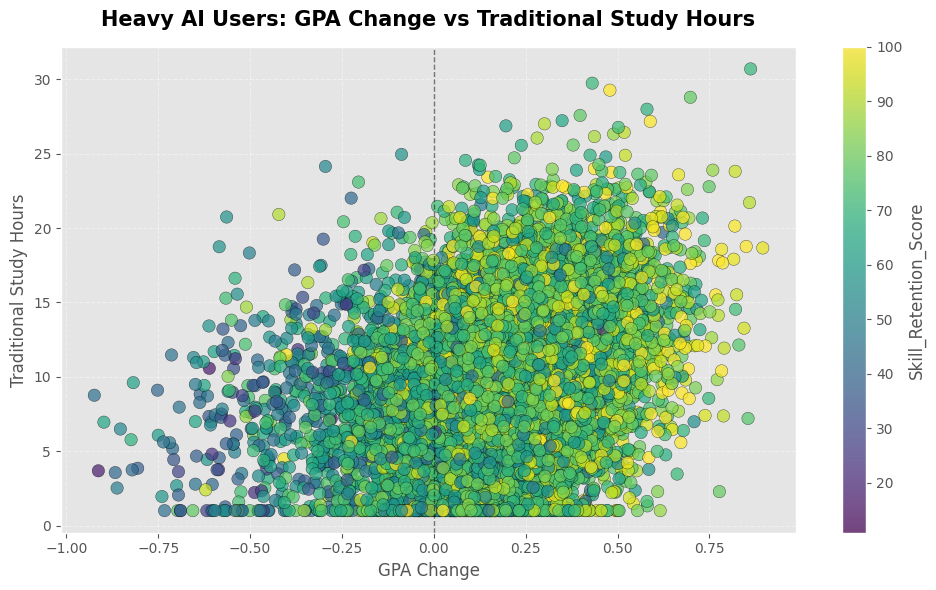

In [122]:
plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    high_geni_usage["Gpa_Change"],
    high_geni_usage["Traditional_Study_Hours"],
    c=high_geni_usage["Skill_Retention_Score"],
    s=80,
    alpha=0.7,
    cmap="viridis",
    edgecolors="black",
    linewidth=0.3,
)

cbar = plt.colorbar(scatter)
cbar.set_label("Skill_Retention_Score")

ax.set_title(
    "Heavy AI Users: GPA Change vs Traditional Study Hours",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel("GPA Change", fontsize=12)

ax.set_ylabel("Traditional Study Hours", fontsize=12)

ax.axvline(x=0, linestyle="--", linewidth=1, color="black", alpha=0.5)

ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

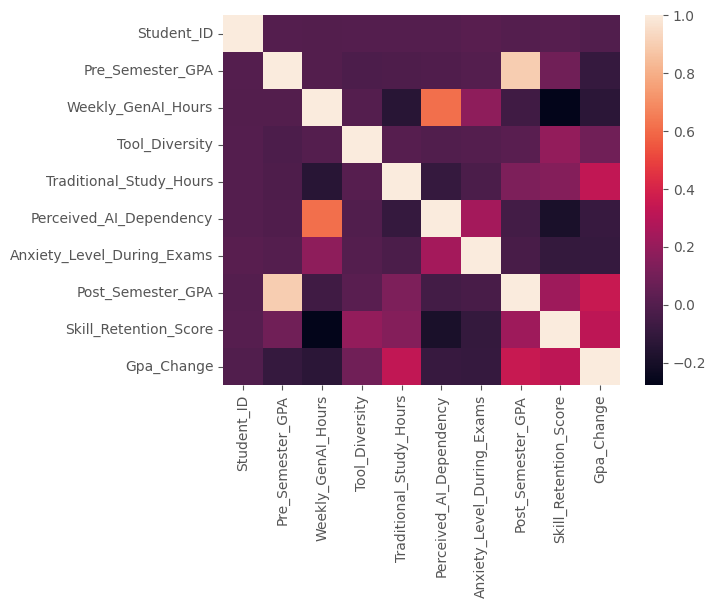

In [135]:
sns.heatmap(
    high_geni_usage.select_dtypes(exclude=["object", "bool"])
    .drop(columns="GenAI_Hour_Bins")
    .corr(),
    annot=False,
)
plt.show()